In [1]:
#importing the libraries
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the data and split it into train and test 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
#Get the image shape
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


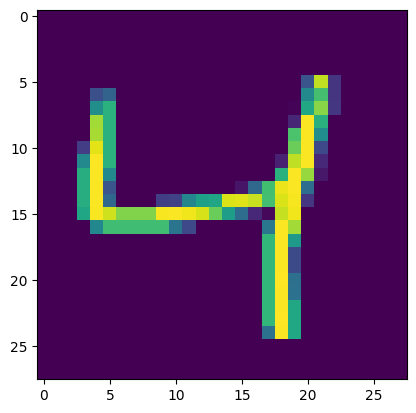

In [4]:
plt.imshow(X_train[2])

In [5]:
# Reshaping the data to fit the model
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [6]:
# One-Hot Encoding:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# Print the new label
print(y_train_one_hot[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
model = Sequential()
model.add(Conv2D(64, kernel_size=3, activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# patience: Number of epochs with no improvement after which training will be stopped.
# restore_best_weights: Whether to restore model weights from the epoch with the best value of the monitored quantity.

# Then, in your model.fit:
# hist = model.fit(..., callbacks=[early_stopping])

In [10]:
# Train the model
hist = model.fit(X_train, y_train_one_hot, validation_data=(X_test, y_test_one_hot), epochs=10,callbacks=[early_stopping])


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8157 - loss: 1.2165 - val_accuracy: 0.9757 - val_loss: 0.0841
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9535 - loss: 0.1586 - val_accuracy: 0.9793 - val_loss: 0.0657
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9658 - loss: 0.1147 - val_accuracy: 0.9848 - val_loss: 0.0477
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9721 - loss: 0.0948 - val_accuracy: 0.9836 - val_loss: 0.0520
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9753 - loss: 0.0886 - val_accuracy: 0.9853 - val_loss: 0.0445
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9766 - loss: 0.0769 - val_accuracy: 0.9839 - val_loss: 0.0544
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9775 - loss: 0.0733 - val_accuracy: 0.9865 - val_loss: 0.0433
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9790 -

--- Training History ---
Final Training Accuracy: 0.9818
Final Validation Accuracy: 0.9873
Final Training Loss: 0.0592
Final Validation Loss: 0.0494

--- Model Evaluation on Test Data ---
Test Loss: 0.0433
Test Accuracy: 0.9865
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10

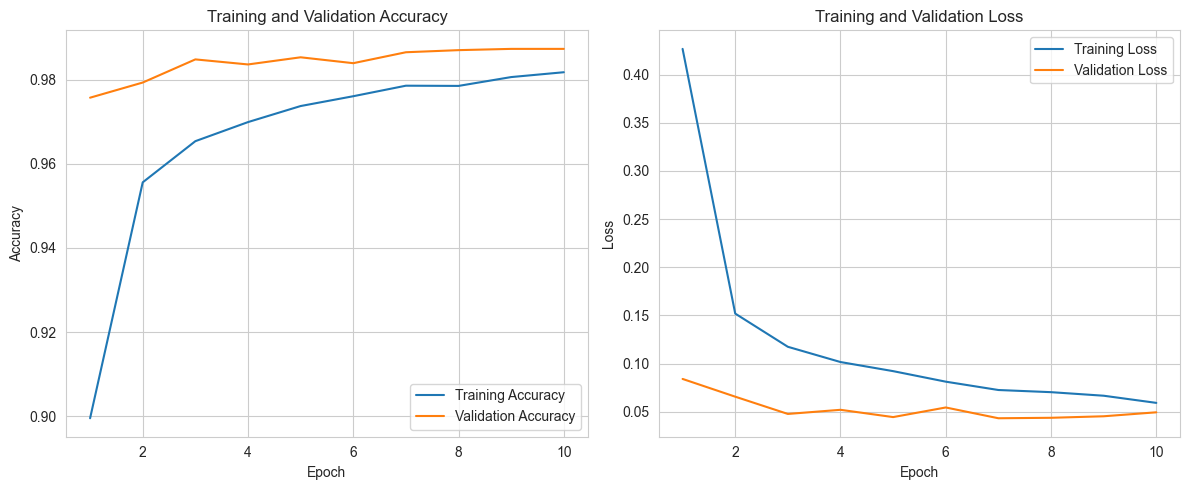

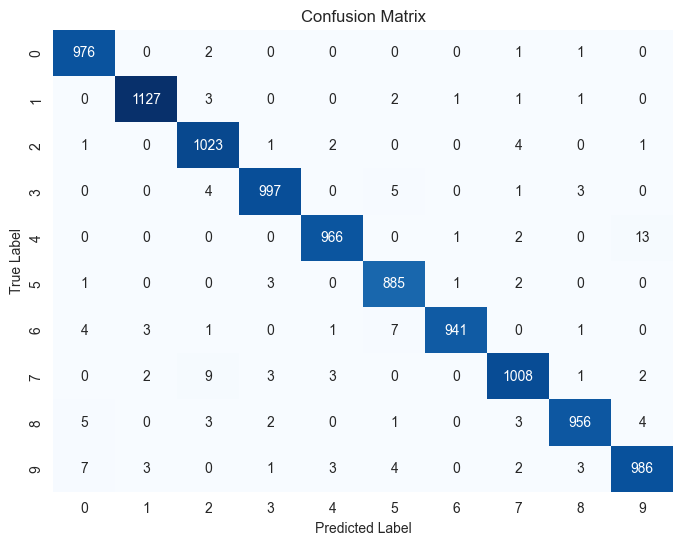

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Get Accuracy and Loss from Training History ---
print("--- Training History ---")
print(f"Final Training Accuracy: {hist.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {hist.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {hist.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {hist.history['val_loss'][-1]:.4f}")

# --- 2. Evaluate the Model on Test Data ---
print("\n--- Model Evaluation on Test Data ---")
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- 3. Make Predictions ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities to class labels
y_true = np.argmax(y_test_one_hot, axis=1) # Convert one-hot to class labels

# --- 4. Detailed Evaluation Metrics (Scikit-learn) ---
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# --- 5. Visualizations with Seaborn ---

# Set style for plots
sns.set_style("whitegrid")

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1, len(hist.history['accuracy']) + 1), y=hist.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=range(1, len(hist.history['val_accuracy']) + 1), y=hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
sns.lineplot(x=range(1, len(hist.history['loss']) + 1), y=hist.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, len(hist.history['val_loss']) + 1), y=hist.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true)) # Assuming class labels are 0, 1, 2...
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Shape of the preprocessed image for prediction: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


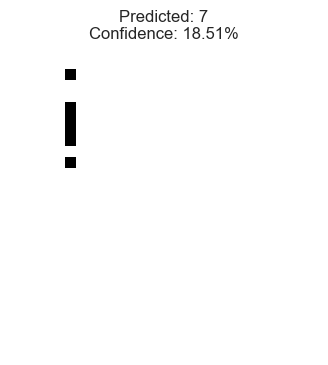


Raw prediction probabilities: [0.06243381 0.14580429 0.15653062 0.08473837 0.18264942 0.05708054
 0.02321965 0.18512356 0.04732703 0.0550926 ]
The model predicts the image is a '7' with 18.51% confidence.


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Your Trained Model ---
# Assuming your model object 'model' is still in memory.
# If you're running this in a new session, you'll need to load it.
# If you saved your model earlier:
# from tensorflow.keras.models import load_model
# model = load_model('path/to/your/saved_model.h5')
# Replace 'path/to/your/saved_model.h5' with the actual path if you saved it.

# --- 2. Define Image Path and Class Names ---
image_path = '8.jpg' # Replace with the actual path to your image
# Make sure these class names match the order of your one-hot encoded labels
class_names = [str(i) for i in range(10)] # Assuming 10 classes, 0-9 for MNIST/Fashion MNIST
# If you have specific class names (e.g., for Fashion MNIST), define them here:
# class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 3. Preprocess the Image ---
# The preprocessing steps *must* match what you did for your training data (X_train).
# Common steps include: resizing, converting to grayscale (if applicable), normalizing.

# Load the image
img = image.load_img(image_path, color_mode='grayscale', target_size=(28, 28)) # Adjust target_size if your images are different

# Convert to a NumPy array
img_array = image.img_to_array(img)

# Expand dimensions to create a batch of 1 (required by model.predict)
# If your model expects (batch_size, height, width, channels), then:
img_array = np.expand_dims(img_array, axis=0) # Becomes (1, 28, 28, 1)

# Normalize the image pixels (important! Match your training normalization)
# If you normalized your training data to 0-1 range:
img_array = img_array / 255.0

# If you reshaped your data for training (e.g., for a Dense layer input in a simple MLP)
# img_array = img_array.reshape(1, 28*28) # Or whatever shape your model expects

print(f"Shape of the preprocessed image for prediction: {img_array.shape}")

# --- 4. Make a Prediction ---
predictions = model.predict(img_array)

# The output `predictions` will be an array of probabilities (e.g., [0.01, 0.05, ..., 0.92]).
# Get the predicted class (the one with the highest probability)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions[0]) * 100

# --- 5. Display the Result ---
plt.figure(figsize=(6, 4))
plt.imshow(img.convert('RGB')) # Display the original image (convert to RGB if it was grayscale)
plt.title(f"Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

print(f"\nRaw prediction probabilities: {predictions[0]}")
print(f"The model predicts the image is a '{predicted_class_name}' with {confidence:.2f}% confidence.")

In [2]:
# Save the full model after training
from tensorflow.keras.models import load_model
model = load_model('model.h5')
model.build(input_shape=(None, 28, 28, 1)) # (None for batch size)
model.save("model.h5")